# Chapter 41: Homographies

## Objective

In this tutorial we will build a homography estimator from scratch in PyTorch, validate it on synthetic point correspondences, study when the method works well or breaks down, and finish with a synthetic perspective-correction example.

By the end of the notebook you should be able to:

- explain what a planar homography does,
- move between Euclidean and homogeneous coordinates,
- estimate a homography with the normalized DLT algorithm,
- measure reprojection error,
- use RANSAC to reject outliers,
- warp a planar image patch with inverse warping,
- and recognize common failure modes such as degeneracy and overwhelming outlier rates.


## Plain-English Introduction

A **homography** is a 3x3 matrix that maps points from one image plane to another when the scene is planar, or when the camera motion can be approximated as a pure rotation around its optical center.

This notebook stays intentionally narrow: it is an **educational homography demo** built on synthetic data so that the geometry is easy to see. The goal is not to build a production panorama stitcher. The goal is to help beginners see how the math, the point correspondences, the robust estimation, and the final perspective correction all fit together.

We will use a **PyTorch implementation of DLT, RANSAC, and inverse warping** to:

- visualize how one plane is warped into another,
- estimate a homography from noisy correspondences,
- measure reprojection error,
- use RANSAC to reject outliers,
- and rectify a synthetic checkerboard with inverse warping.

**What to notice:** the notebook repeatedly moves between pictures and equations. Every major step now has a beginner-friendly visual intuition, so you can connect the matrix notation to something geometric on the page.


## The Math: Homogeneous Coordinates and $\tilde{\mathbf{p}}' \sim H\tilde{\mathbf{p}}$

A 2D point $\mathbf{p} = (x, y)$ becomes a **homogeneous** 3-vector by appending a 1:

$$
\tilde{\mathbf{p}} = \begin{bmatrix}x \\ y \\ 1\end{bmatrix}.
$$

A homography is a non-singular matrix

$$
H \in \mathbb{R}^{3 \times 3}, \qquad
\tilde{\mathbf{p}}' \sim H\tilde{\mathbf{p}}.
$$

The symbol $\sim$ means **equal up to scale**. In homogeneous coordinates, multiplying a point by any nonzero scalar does not change the represented Euclidean point. After applying $H$, we convert back to Euclidean coordinates by dividing by the last component:

$$
\tilde{\mathbf{p}}' = \begin{bmatrix}u \\ v \\ w\end{bmatrix}
\quad \Rightarrow \quad
\mathbf{p}' = \left(\frac{u}{w}, \frac{v}{w}\right).
$$

Because $H$ is defined only up to a scale factor, we should compare estimated and ground-truth homographies **after normalizing them to a common scale**.

A beginner-friendly counting argument is useful here. A homography is written as a 3x3 matrix, which suggests 9 entries, but multiplying the whole matrix by any nonzero constant gives the same geometric mapping. That means one overall scale is arbitrary, so the homography has **8 degrees of freedom**, not 9. Each point correspondence contributes two constraints, one for the destination x-coordinate and one for the destination y-coordinate. Therefore **four non-collinear point pairs** are the minimum needed for DLT, while using more than four correspondences gives an overdetermined least-squares system.

To estimate $H$ from correspondences, we will use the **normalized Direct Linear Transform (DLT)**:

1. normalize source and destination points for numerical stability,
2. write the linear constraints implied by each correspondence,
3. solve the resulting homogeneous system with SVD,
4. denormalize the result back into the original coordinate system.

DLT also needs point configurations that constrain the full 2D projective warp. If all correspondences are collinear or nearly collinear, the system becomes poorly conditioned because the data do not sufficiently constrain the whole plane. This notebook intentionally demonstrates that degeneracy as a failure case later on. The implementation here stays educational and does not add a full degeneracy-filtering system, but production homography estimators often reject degenerate samples before accepting a fit.

**What to notice:** the last coordinate $w$ is not just bookkeeping. It is what lets a matrix represent perspective effects, and dividing by $w$ is the step that brings the transformed point back to ordinary 2D coordinates.


PyTorch version: 2.12.1
Default dtype: torch.float64
Device: CPU
Figure output directory: /Users/yangruimeng/Desktop/projects/eng-ai-agents-clean/notebooks/CV/mit-foundations/chapter-41-homographies/images
Saved figure: images/fig41_02_homogeneous_coordinates.png


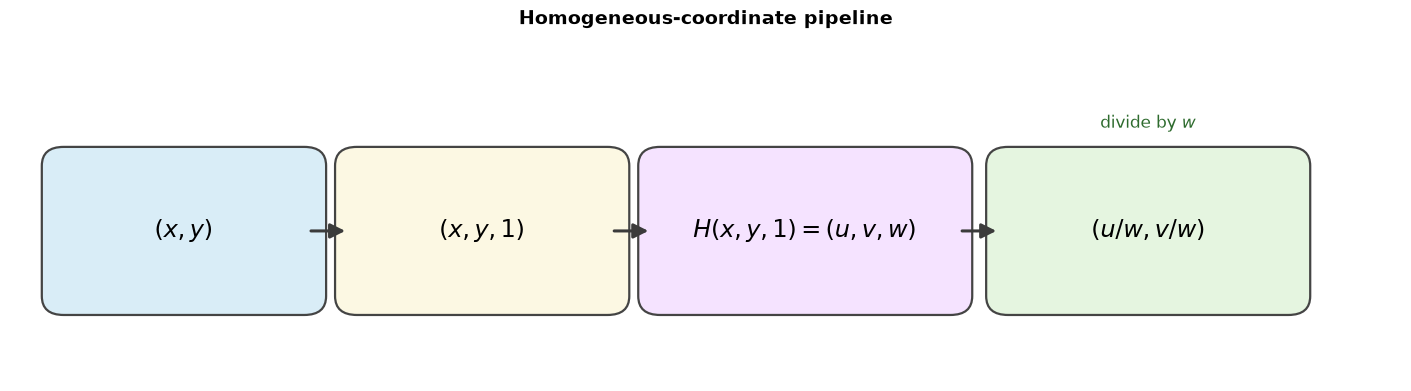

In [88]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Polygon
import torch


torch.set_default_dtype(torch.float64)
torch.manual_seed(7)
random.seed(7)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
    }
)

CHAPTER_DIR = Path("notebooks/CV/mit-foundations/chapter-41-homographies")
if not CHAPTER_DIR.exists():
    CHAPTER_DIR = Path(".")
IMAGE_DIR = CHAPTER_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig: plt.Figure, filename: str, dpi: int = 220) -> None:
    path = IMAGE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved figure: {path}")


print("PyTorch version:", torch.__version__)
print("Default dtype:", torch.get_default_dtype())
print("Device: CPU")
print("Figure output directory:", IMAGE_DIR.resolve())


fig, ax = plt.subplots(figsize=(14, 3.8), constrained_layout=True)
ax.set_axis_off()
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)

boxes = [
    (0.5, 0.95, 2.5, 1.6, "#d9edf7", r"$(x, y)$"),
    (3.45, 0.95, 2.6, 1.6, "#fcf8e3", r"$(x, y, 1)$"),
    (6.5, 0.95, 3.0, 1.6, "#f5e3ff", r"$H(x, y, 1) = (u, v, w)$"),
    (10.0, 0.95, 2.9, 1.6, "#e5f5e0", r"$(u / w, v / w)$"),
]

for x, y, w, h, color, label in boxes:
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.18,rounding_size=0.22",
        linewidth=1.6,
        edgecolor="#444444",
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=17)

for x0, x1 in [(3.0, 3.4), (6.05, 6.45), (9.55, 9.95)]:
    ax.add_patch(
        FancyArrowPatch((x0, 1.75), (x1, 1.75), arrowstyle="-|>", mutation_scale=22, linewidth=2.2, color="#3b3b3b")
    )

ax.text(11.45, 2.95, "divide by $w$", ha="center", fontsize=12, color="#2e6b2e")
ax.set_title("Homogeneous-coordinate pipeline", pad=10)
save_figure(fig, "fig41_02_homogeneous_coordinates.png")
plt.show()



## Synthetic Data Setup

We will create a regular 2D grid of points, define a known homography, and use it to generate perfect correspondences. This gives us a clean baseline before we introduce noise and outliers.


In [89]:
def to_homogeneous(points: torch.Tensor) -> torch.Tensor:
    """Append a 1 to each 2D point."""
    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError("Expected points with shape (N, 2).")
    ones = torch.ones((points.shape[0], 1), dtype=points.dtype, device=points.device)
    return torch.cat([points, ones], dim=1)


def from_homogeneous(points: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """Convert homogeneous points back to Euclidean coordinates."""
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError("Expected homogeneous points with shape (N, 3).")
    scale = points[:, 2:].clone()
    scale = torch.where(scale.abs() < eps, torch.full_like(scale, eps), scale)
    return points[:, :2] / scale


def apply_homography(points: torch.Tensor, H: torch.Tensor) -> torch.Tensor:
    """Apply a 3x3 homography to 2D points."""
    if H.shape != (3, 3):
        raise ValueError("Expected H with shape (3, 3).")
    warped = to_homogeneous(points) @ H.T
    return from_homogeneous(warped)


def normalize_points(points: torch.Tensor, eps: float = 1e-12) -> tuple[torch.Tensor, torch.Tensor]:
    """Normalize points so the centroid is at the origin and mean distance is sqrt(2)."""
    centroid = points.mean(dim=0)
    centered = points - centroid
    mean_dist = torch.linalg.norm(centered, dim=1).mean().clamp(min=eps)
    scale = math.sqrt(2.0) / mean_dist

    T = torch.tensor(
        [
            [scale, 0.0, -scale * centroid[0]],
            [0.0, scale, -scale * centroid[1]],
            [0.0, 0.0, 1.0],
        ],
        dtype=points.dtype,
        device=points.device,
    )
    normalized = apply_homography(points, T)
    return normalized, T


def estimate_homography_dlt(src_points: torch.Tensor, dst_points: torch.Tensor) -> torch.Tensor:
    """Estimate a homography with normalized DLT."""
    if src_points.shape != dst_points.shape or src_points.shape[0] < 4:
        raise ValueError("Need at least four matching point pairs.")

    src_norm, T_src = normalize_points(src_points)
    dst_norm, T_dst = normalize_points(dst_points)

    rows = []
    for (x, y), (u, v) in zip(src_norm, dst_norm):
        rows.append(
            torch.tensor(
                [-x, -y, -1.0, 0.0, 0.0, 0.0, u * x, u * y, u],
                dtype=src_points.dtype,
                device=src_points.device,
            )
        )
        rows.append(
            torch.tensor(
                [0.0, 0.0, 0.0, -x, -y, -1.0, v * x, v * y, v],
                dtype=src_points.dtype,
                device=src_points.device,
            )
        )
    A = torch.stack(rows)

    _, _, vh = torch.linalg.svd(A)
    H_norm = vh[-1].reshape(3, 3)
    H = torch.linalg.inv(T_dst) @ H_norm @ T_src
    return H / torch.linalg.norm(H)


def compute_reprojection_error(H: torch.Tensor, src_points: torch.Tensor, dst_points: torch.Tensor) -> torch.Tensor:
    """Compute Euclidean reprojection error for each correspondence."""
    projected = apply_homography(src_points, H)
    return torch.linalg.norm(projected - dst_points, dim=1)


def ransac_homography(
    src_points: torch.Tensor,
    dst_points: torch.Tensor,
    threshold: float,
    num_iters: int,
) -> tuple[torch.Tensor, torch.Tensor, dict]:
    """Estimate a homography robustly with four-point RANSAC."""
    if src_points.shape[0] < 4:
        raise ValueError("RANSAC needs at least four correspondences.")

    n = src_points.shape[0]
    best_H = None
    best_inliers = None
    best_count = -1
    best_mean_error = float("inf")

    for _ in range(num_iters):
        sample_idx = torch.randperm(n)[:4]
        try:
            candidate_H = estimate_homography_dlt(src_points[sample_idx], dst_points[sample_idx])
        except RuntimeError:
            continue

        errors = compute_reprojection_error(candidate_H, src_points, dst_points)
        inliers = errors < threshold
        count = int(inliers.sum().item())
        mean_error = float(errors[inliers].mean().item()) if count > 0 else float("inf")

        if count > best_count or (count == best_count and mean_error < best_mean_error):
            best_H = candidate_H
            best_inliers = inliers
            best_count = count
            best_mean_error = mean_error

    if best_H is None or best_inliers is None or int(best_inliers.sum().item()) < 4:
        raise RuntimeError("RANSAC failed to find a valid homography.")

    refined_H = estimate_homography_dlt(src_points[best_inliers], dst_points[best_inliers])
    refined_errors = compute_reprojection_error(refined_H, src_points, dst_points)
    diagnostics = {
        "mean_inlier_error": float(refined_errors[best_inliers].mean().item()),
        "mean_all_error": float(refined_errors.mean().item()),
        "num_inliers": int(best_inliers.sum().item()),
        "inlier_ratio": float(best_inliers.double().mean().item()),
    }
    return refined_H, best_inliers, diagnostics


def normalize_homography_scale(H: torch.Tensor) -> torch.Tensor:
    """Normalize a homography so it can be compared up to scale."""
    if abs(float(H[-1, -1])) > 1e-12:
        return H / H[-1, -1]
    return H / torch.linalg.norm(H)


def make_grid(num_x: int = 6, num_y: int = 6, spacing: float = 1.0) -> torch.Tensor:
    xs = torch.linspace(-2.5, 2.5, steps=num_x) * spacing
    ys = torch.linspace(-2.0, 2.0, steps=num_y) * spacing
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    return torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)


def draw_process_box(ax, xy, width, height, text, facecolor):
    patch = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.18",
        linewidth=1.5,
        edgecolor="#3f3f3f",
        facecolor=facecolor,
    )
    ax.add_patch(patch)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=11,
    )


src_grid = make_grid()
H_gt = torch.tensor(
    [
        [1.10, 0.18, 1.20],
        [-0.12, 0.95, -0.60],
        [0.015, 0.020, 1.00],
    ]
)

dst_grid_clean = apply_homography(src_grid, H_gt)
print("Number of correspondences:", src_grid.shape[0])
print("Ground-truth H:")
print(normalize_homography_scale(H_gt))


Number of correspondences: 36
Ground-truth H:
tensor([[ 1.1000,  0.1800,  1.2000],
        [-0.1200,  0.9500, -0.6000],
        [ 0.0150,  0.0200,  1.0000]])


## Visualizing the Known Transformation

The next figure is the first big geometric picture in the notebook: a regular source grid on one plane and the warped grid on the destination plane. A homography bends the square boundary into a quadrilateral while still preserving straight lines.

**What this figure shows:** `fig41_01_homography_intuition.png` is the conceptual plane-to-plane view. `fig41_06_grid_transformation.png` is the more literal before/after coordinate view of the same mapping.

**What to notice:** every source point stays connected to the same underlying plane, but perspective changes spacing, orientation, and apparent parallelism. This is the beginner-friendly visual intuition for what a homography does.

**Why this matters:** DLT and RANSAC are not abstract matrix games. They are trying to recover exactly this planar warp from noisy point matches.

**Four-point intuition:** the labeled corners A, B, C, and D form a non-collinear quadrilateral. That picture is the geometric reason four non-collinear correspondences are the minimum for DLT: they are the smallest set that constrains a full planar projective warp rather than only a line-like slice of it.



Saved figure: images/fig41_01_homography_intuition.png


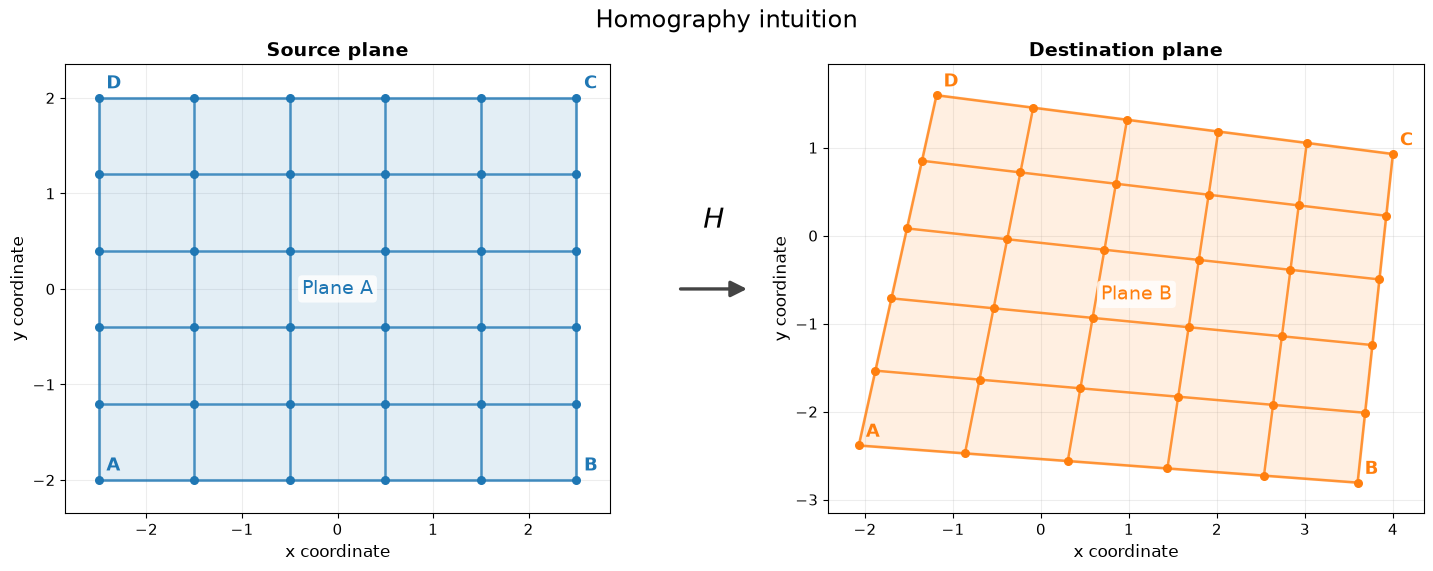

Saved figure: images/fig41_06_grid_transformation.png


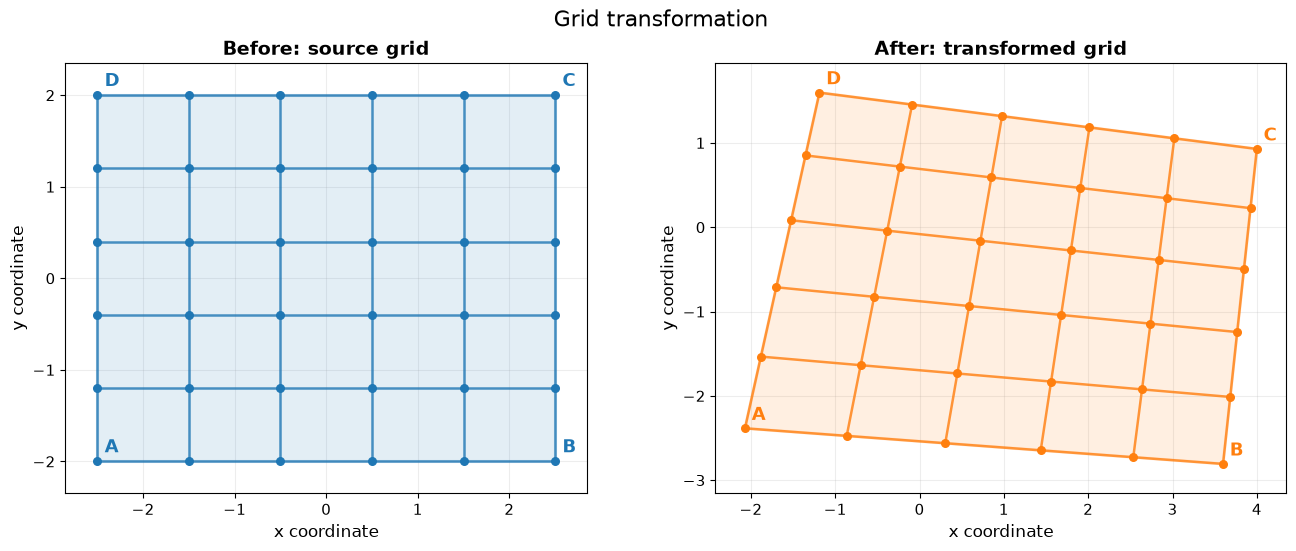

In [90]:
def set_geometry_limits(ax, points: torch.Tensor, pad: float = 0.35) -> None:
    mins = points.min(dim=0).values
    maxs = points.max(dim=0).values
    ax.set_xlim(float(mins[0] - pad), float(maxs[0] + pad))
    ax.set_ylim(float(mins[1] - pad), float(maxs[1] + pad))


def plot_grid(
    ax,
    points: torch.Tensor,
    title: str,
    color: str = "tab:blue",
    polygon: torch.Tensor | None = None,
    polygon_label: str | None = None,
) -> None:
    pts = points.reshape(6, 6, 2)
    for row in pts:
        ax.plot(row[:, 0], row[:, 1], color=color, alpha=0.8, linewidth=1.8)
    for col in pts.permute(1, 0, 2):
        ax.plot(col[:, 0], col[:, 1], color=color, alpha=0.8, linewidth=1.8)
    ax.scatter(points[:, 0], points[:, 1], s=30, color=color, zorder=3)

    if polygon is not None:
        poly = Polygon(
            polygon.tolist(),
            closed=True,
            facecolor=color,
            edgecolor=color,
            linewidth=2.3,
            alpha=0.12,
            zorder=2,
        )
        ax.add_patch(poly)
        labels = ["A", "B", "C", "D"]
        for label, (x, y) in zip(labels, polygon.tolist()):
            ax.text(x + 0.08, y + 0.10, label, fontsize=13, weight="bold", color=color)
        if polygon_label is not None:
            center = polygon.mean(dim=0)
            ax.text(
                center[0],
                center[1],
                polygon_label,
                fontsize=14,
                ha="center",
                va="center",
                color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
            )

    ax.set_title(title)
    ax.set_xlabel("x coordinate")
    ax.set_ylabel("y coordinate")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.22)
    set_geometry_limits(ax, points if polygon is None else torch.cat([points, polygon], dim=0))


src_square = torch.tensor(
    [
        [-2.5, -2.0],
        [2.5, -2.0],
        [2.5, 2.0],
        [-2.5, 2.0],
    ]
)
dst_square = apply_homography(src_square, H_gt)

fig = plt.figure(figsize=(14.5, 5.6), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=[1.0, 0.14, 1.0])
ax_left = fig.add_subplot(grid[0, 0])
ax_mid = fig.add_subplot(grid[0, 1])
ax_right = fig.add_subplot(grid[0, 2])
plot_grid(ax_left, src_grid, "Source plane", color="tab:blue", polygon=src_square, polygon_label="Plane A")
plot_grid(ax_right, dst_grid_clean, "Destination plane", color="tab:orange", polygon=dst_square, polygon_label="Plane B")
ax_mid.set_axis_off()
ax_mid.set_xlim(0, 1)
ax_mid.set_ylim(0, 1)
ax_mid.add_patch(FancyArrowPatch((0.1, 0.5), (0.9, 0.5), arrowstyle="-|>", mutation_scale=24, linewidth=2.4, color="#444444"))
ax_mid.text(0.5, 0.62, "$H$", ha="center", va="bottom", fontsize=20)
fig.suptitle("Homography intuition", fontsize=17)
save_figure(fig, "fig41_01_homography_intuition.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), constrained_layout=True)
plot_grid(axes[0], src_grid, "Before: source grid", color="tab:blue", polygon=src_square)
plot_grid(axes[1], dst_grid_clean, "After: transformed grid", color="tab:orange", polygon=dst_square)
fig.suptitle("Grid transformation", fontsize=16)
save_figure(fig, "fig41_06_grid_transformation.png")
plt.show()



## Noisy Correspondences and Outliers

Real feature matches are never perfect. We will perturb the destination points with Gaussian noise and then replace a fraction of them with random outliers. This lets us test both least-squares estimation and robust estimation under controlled conditions.

**What to notice:** some destination points stay close to the clean warp, while the outliers jump far away. Those few bad matches are enough to damage a plain least-squares fit.

**Takeaway:** the hard part is not only estimating a homography. It is deciding which correspondences deserve to influence the estimate.


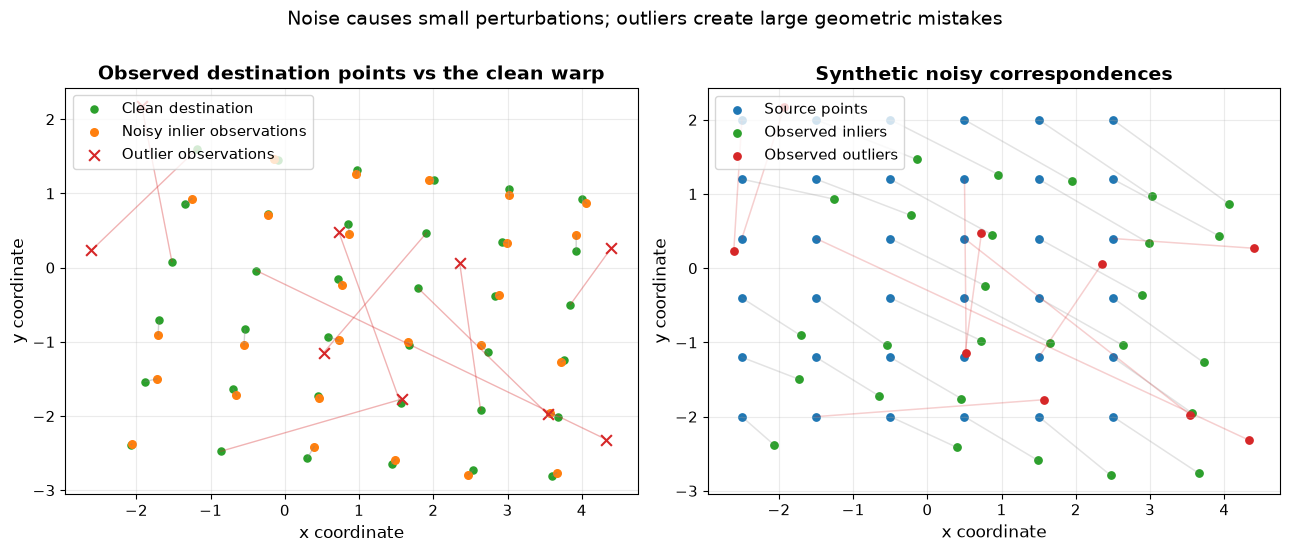

True inlier ratio: 0.75


In [91]:
def generate_correspondences(
    H: torch.Tensor,
    noise_std: float = 0.05,
    outlier_ratio: float = 0.2,
    num_x: int = 6,
    num_y: int = 6,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    src = make_grid(num_x=num_x, num_y=num_y)
    dst_clean = apply_homography(src, H)
    dst_noisy = dst_clean + noise_std * torch.randn_like(dst_clean)

    num_points = src.shape[0]
    num_outliers = int(round(outlier_ratio * num_points))
    true_inliers = torch.ones(num_points, dtype=torch.bool)

    if num_outliers > 0:
        outlier_idx = torch.randperm(num_points)[:num_outliers]
        mins = dst_clean.min(dim=0).values - 1.0
        maxs = dst_clean.max(dim=0).values + 1.0
        random_points = mins + (maxs - mins) * torch.rand((num_outliers, 2), dtype=dst_noisy.dtype)
        dst_noisy[outlier_idx] = random_points
        true_inliers[outlier_idx] = False

    return src, dst_clean, dst_noisy, true_inliers


src_points, dst_clean, dst_points, true_inliers = generate_correspondences(
    H_gt,
    noise_std=0.08,
    outlier_ratio=0.25,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(dst_clean[:, 0], dst_clean[:, 1], label="Clean destination", color="tab:green", s=26)
axes[0].scatter(dst_points[true_inliers, 0], dst_points[true_inliers, 1], label="Noisy inlier observations", color="tab:orange", s=30)
axes[0].scatter(
    dst_points[~true_inliers, 0],
    dst_points[~true_inliers, 1],
    label="Outlier observations",
    color="tab:red",
    marker="x",
    s=60,
)
for i in range(dst_clean.shape[0]):
    line_color = "tab:red" if not bool(true_inliers[i]) else "gray"
    axes[0].plot(
        [dst_clean[i, 0], dst_points[i, 0]],
        [dst_clean[i, 1], dst_points[i, 1]],
        color=line_color,
        alpha=0.35,
        linewidth=1,
    )
axes[0].set_title("Observed destination points vs the clean warp")
axes[0].set_xlabel("x coordinate")
axes[0].set_ylabel("y coordinate")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper left")

axes[1].scatter(src_points[:, 0], src_points[:, 1], label="Source points", color="tab:blue", s=28)
axes[1].scatter(dst_points[true_inliers, 0], dst_points[true_inliers, 1], label="Observed inliers", color="tab:green", s=28)
axes[1].scatter(dst_points[~true_inliers, 0], dst_points[~true_inliers, 1], label="Observed outliers", color="tab:red", s=28)
for i in range(src_points.shape[0]):
    line_color = "tab:red" if not bool(true_inliers[i]) else "gray"
    axes[1].plot(
        [src_points[i, 0], dst_points[i, 0]],
        [src_points[i, 1], dst_points[i, 1]],
        color=line_color,
        alpha=0.22,
        linewidth=1.1,
    )
axes[1].set_title("Synthetic noisy correspondences")
axes[1].set_xlabel("x coordinate")
axes[1].set_ylabel("y coordinate")
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper left")

fig.suptitle("Noise causes small perturbations; outliers create large geometric mistakes", fontsize=14)
plt.tight_layout()
plt.show()

print("True inlier ratio:", true_inliers.double().mean().item())


## Estimation in PyTorch: DLT vs RANSAC

We will first estimate a homography from all correspondences using normalized DLT. Then we will run RANSAC to repeatedly sample four points, score the candidate by reprojection error, and refit on the best inlier set.

The next outputs include:

- a simple **DLT pipeline diagram**,
- a **reprojection-error intuition plot** showing observed vs predicted destination points,
- and the usual numerical comparison between plain DLT and robust RANSAC.

**What to notice:** DLT answers the question "which matrix best explains these equations?" RANSAC adds the question "which correspondences should we trust before we solve those equations?"

**Normalized DLT detail:** the SVD step recovers a normalized homography $H_{	ext{norm}}$. We then map it back to the original coordinate system with
$$
H = T_{\mathrm{dst}}^{-1} H_{\mathrm{norm}} T_{\mathrm{src}}.
$$
That denormalization step is why point normalization improves numerical stability without changing the final geometric mapping.



Saved figure: images/fig41_03_dlt_pipeline.png


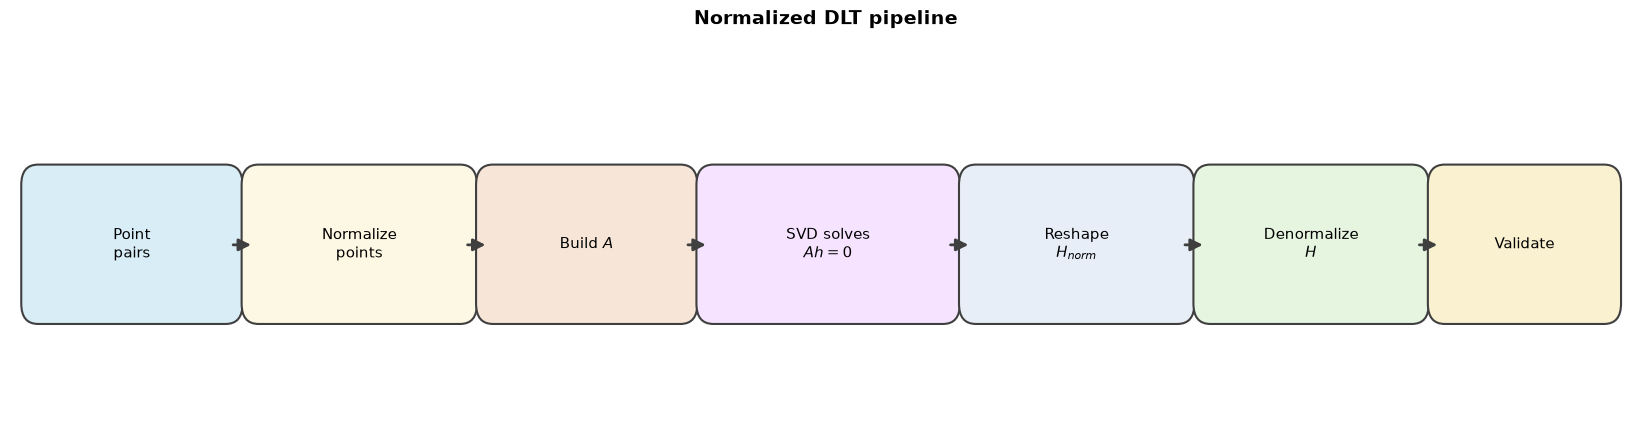

Saved figure: images/fig41_07_reprojection_error.png


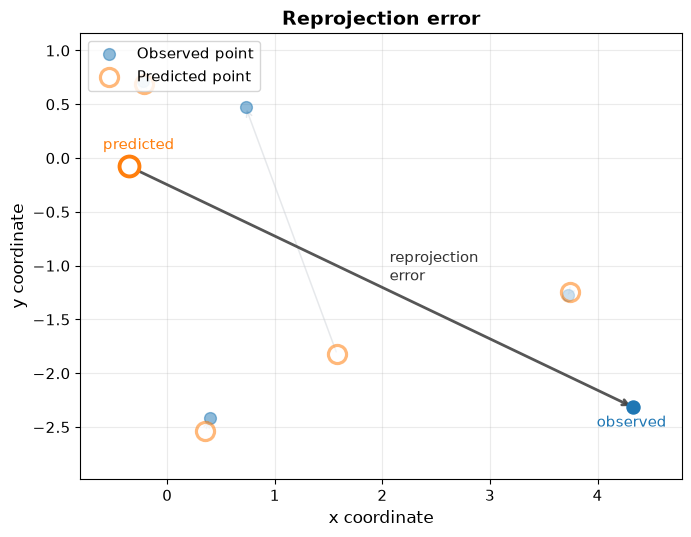

DLT mean reprojection error:    1.0240097483168153
RANSAC mean reprojection error: 0.6730099428317433
RANSAC diagnostics: {'mean_inlier_error': 0.08344928815809409, 'mean_all_error': 0.6730099428317433, 'num_inliers': 25, 'inlier_ratio': 0.6944444444444444}
Highlighted reprojection pair index: 19


In [92]:
fig, ax = plt.subplots(figsize=(16.4, 4.1), constrained_layout=True)
ax.set_axis_off()
ax.set_xlim(0, 17.4)
ax.set_ylim(0, 3.3)

dlt_boxes = [
    ((0.3, 0.95), 2.0, 1.05, "Point\npairs", "#d9edf7"),
    ((2.65, 0.95), 2.15, 1.05, "Normalize\npoints", "#fcf8e3"),
    ((5.15, 0.95), 2.0, 1.05, "Build $A$", "#f7e5d7"),
    ((7.5, 0.95), 2.45, 1.05, "SVD solves\n$Ah = 0$", "#f5e3ff"),
    ((10.3, 0.95), 2.15, 1.05, "Reshape\n$H_{norm}$", "#e8eef7"),
    ((12.8, 0.95), 2.15, 1.05, "Denormalize\n$H$", "#e5f5e0"),
    ((15.3, 0.95), 1.7, 1.05, "Validate", "#f9f1d0"),
]
for xy, w, h, text, color in dlt_boxes:
    draw_process_box(ax, xy, w, h, text, color)
for x0, x1 in [(2.35, 2.6), (4.85, 5.1), (7.2, 7.45), (10.0, 10.25), (12.5, 12.75), (15.0, 15.25)]:
    ax.add_patch(FancyArrowPatch((x0, 1.47), (x1, 1.47), arrowstyle="-|>", mutation_scale=18, linewidth=2.0, color="#3f3f3f"))
ax.set_title("Normalized DLT pipeline", pad=10)
save_figure(fig, "fig41_03_dlt_pipeline.png")
plt.show()

H_dlt = estimate_homography_dlt(src_points, dst_points)
errors_dlt = compute_reprojection_error(H_dlt, src_points, dst_points)

H_ransac, predicted_inliers, ransac_info = ransac_homography(
    src_points,
    dst_points,
    threshold=0.20,
    num_iters=400,
)
errors_ransac = compute_reprojection_error(H_ransac, src_points, dst_points)
projected_ransac = apply_homography(src_points, H_ransac)

selected_idx = torch.tensor([2, 9, 17, 25, int(torch.argmax(errors_ransac).item())], dtype=torch.long)
observed_small = dst_points[selected_idx]
predicted_small = projected_ransac[selected_idx]
error_small = errors_ransac[selected_idx]
highlight_local = int(torch.argmax(error_small).item())
highlight_global = int(selected_idx[highlight_local].item())

fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
ax.scatter(observed_small[:, 0], observed_small[:, 1], color="#1f77b4", s=72, alpha=0.5, label="Observed point", zorder=3)
ax.scatter(predicted_small[:, 0], predicted_small[:, 1], facecolors="white", edgecolors="#ff7f0e", linewidths=2.3, s=170, alpha=0.55, label="Predicted point", zorder=4)
for i in range(len(selected_idx)):
    color = "#444444" if i == highlight_local else "#c9ced4"
    width = 2.0 if i == highlight_local else 1.1
    alpha = 0.9 if i == highlight_local else 0.45
    ax.annotate(
        "",
        xy=(observed_small[i, 0], observed_small[i, 1]),
        xytext=(predicted_small[i, 0], predicted_small[i, 1]),
        arrowprops=dict(arrowstyle="->", color=color, linewidth=width, alpha=alpha),
        zorder=2,
    )

ax.scatter([observed_small[highlight_local, 0]], [observed_small[highlight_local, 1]], color="#1f77b4", s=88, alpha=1.0, zorder=5)
ax.scatter([predicted_small[highlight_local, 0]], [predicted_small[highlight_local, 1]], facecolors="white", edgecolors="#ff7f0e", linewidths=2.8, s=205, alpha=1.0, zorder=6)
ax.text(predicted_small[highlight_local, 0] - 0.24, predicted_small[highlight_local, 1] + 0.16, "predicted", color="#ff7f0e", fontsize=11)
ax.text(observed_small[highlight_local, 0] - 0.34, observed_small[highlight_local, 1] - 0.18, "observed", color="#1f77b4", fontsize=11)
midpoint = 0.5 * (predicted_small[highlight_local] + observed_small[highlight_local])
ax.text(midpoint[0] + 0.08, midpoint[1] + 0.06, "reprojection\nerror", fontsize=11, color="#333333")
ax.set_title("Reprojection error")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=True)
set_geometry_limits(ax, torch.cat([observed_small, predicted_small], dim=0), pad=0.45)
save_figure(fig, "fig41_07_reprojection_error.png")
plt.show()

print("DLT mean reprojection error:   ", float(errors_dlt.mean().item()))
print("RANSAC mean reprojection error:", float(errors_ransac.mean().item()))
print("RANSAC diagnostics:", ransac_info)
print("Highlighted reprojection pair index:", highlight_global)



## Visualizing RANSAC Inliers and Outliers

The plot below colors the matched destination points by whether RANSAC classified them as inliers or outliers. This gives a direct picture of why robust estimation improves the fit.

**What this figure shows:** the left panel is the synthetic ground-truth split and the right panel is RANSAC's estimated split under the same axis limits.

**What to notice:** RANSAC is not trying to explain every point. It is trying to find the largest self-consistent subset of matches and ignore the points that break that consistency.

**Why this matters:** once the inliers are identified, we can refit the homography using only those trustworthy correspondences.



Saved figure: images/fig41_04_ransac_workflow.png


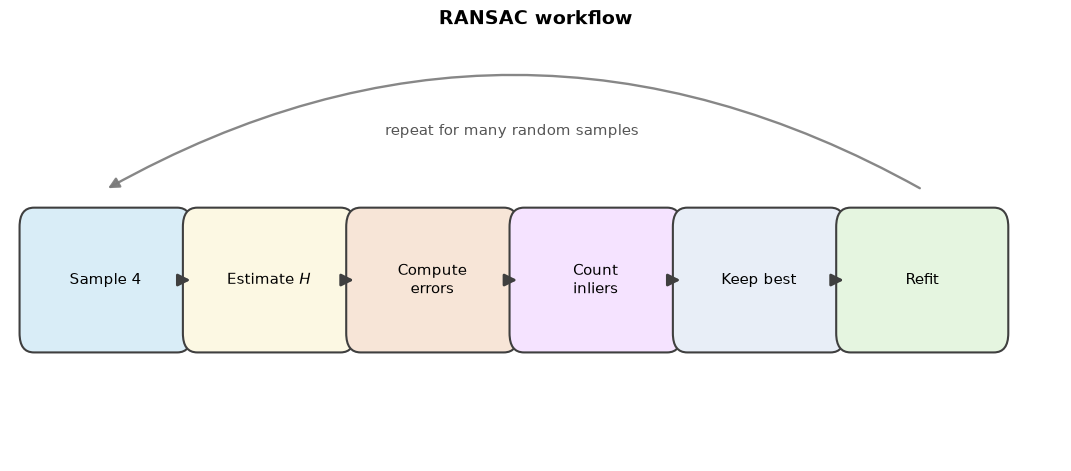

Saved figure: images/fig41_08_ransac_inliers_outliers.png


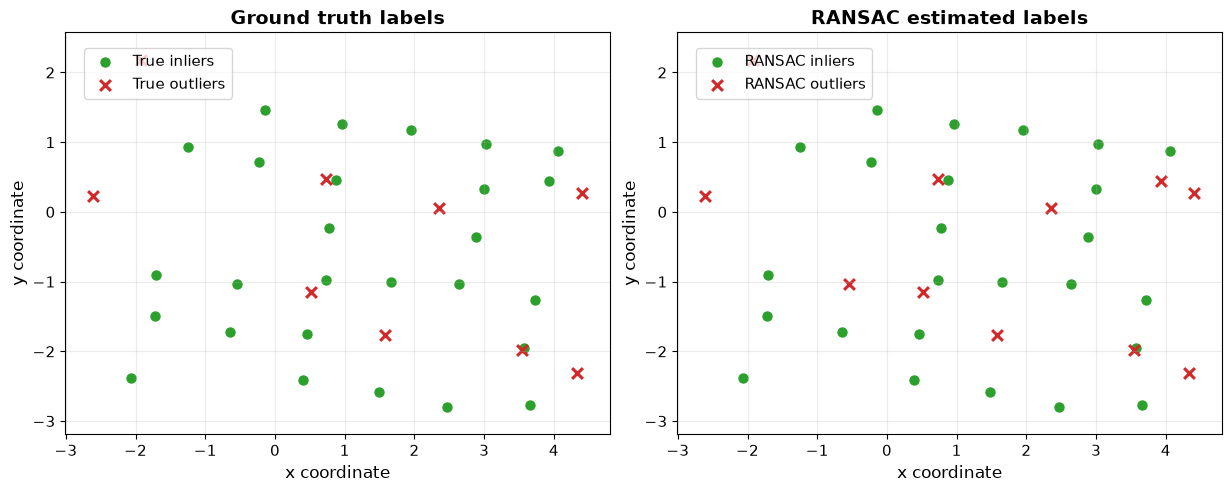

In [93]:
fig, ax = plt.subplots(figsize=(10.6, 4.6), constrained_layout=True)
ax.set_axis_off()
ax.set_xlim(0, 13.2)
ax.set_ylim(0, 4.0)

workflow_steps = [
    ((0.3, 1.2), 1.8, 1.0, "Sample 4", "#d9edf7"),
    ((2.35, 1.2), 1.8, 1.0, "Estimate $H$", "#fcf8e3"),
    ((4.4, 1.2), 1.8, 1.0, "Compute\nerrors", "#f7e5d7"),
    ((6.45, 1.2), 1.8, 1.0, "Count\ninliers", "#f5e3ff"),
    ((8.5, 1.2), 1.8, 1.0, "Keep best", "#e8eef7"),
    ((10.55, 1.2), 1.8, 1.0, "Refit", "#e5f5e0"),
]
for xy, w, h, text, color in workflow_steps:
    draw_process_box(ax, xy, w, h, text, color)
for x0, x1 in [(2.12, 2.3), (4.18, 4.35), (6.22, 6.4), (8.28, 8.45), (10.33, 10.5)]:
    ax.add_patch(FancyArrowPatch((x0, 1.7), (x1, 1.7), arrowstyle="-|>", mutation_scale=18, linewidth=2.0, color="#3f3f3f"))
ax.add_patch(FancyArrowPatch((11.45, 2.55), (1.2, 2.55), connectionstyle="arc3,rad=0.28", arrowstyle="-|>", mutation_scale=16, linewidth=1.7, color="#7a7a7a", alpha=0.9))
ax.text(6.3, 3.1, "repeat for many random samples", ha="center", va="center", fontsize=11, color="#555555")
ax.set_title("RANSAC workflow", pad=8)
save_figure(fig, "fig41_04_ransac_workflow.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.0), constrained_layout=True)
legend_anchor = (0.02, 0.98)
axes[0].scatter(dst_points[true_inliers, 0], dst_points[true_inliers, 1], color="tab:green", s=42, label="True inliers")
axes[0].scatter(dst_points[~true_inliers, 0], dst_points[~true_inliers, 1], color="tab:red", s=60, marker="x", linewidths=2.2, label="True outliers")
axes[0].set_title("Ground truth labels")
axes[0].set_xlabel("x coordinate")
axes[0].set_ylabel("y coordinate")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper left", bbox_to_anchor=legend_anchor, frameon=True)

axes[1].scatter(dst_points[predicted_inliers, 0], dst_points[predicted_inliers, 1], color="tab:green", s=42, label="RANSAC inliers")
axes[1].scatter(dst_points[~predicted_inliers, 0], dst_points[~predicted_inliers, 1], color="tab:red", s=60, marker="x", linewidths=2.2, label="RANSAC outliers")
axes[1].set_title("RANSAC estimated labels")
axes[1].set_xlabel("x coordinate")
axes[1].set_ylabel("y coordinate")
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper left", bbox_to_anchor=legend_anchor, frameon=True)

shared_points = dst_points
for ax in axes:
    set_geometry_limits(ax, shared_points, pad=0.4)

save_figure(fig, "fig41_08_ransac_inliers_outliers.png")
plt.show()



## Validation Against Ground Truth

A homography is only defined up to scale, so we normalize the estimated and true matrices before comparing them. We report three kinds of validation metrics:

- **Frobenius matrix error**: how far the estimated homography matrix is from the ground truth after scale normalization,
- **mean reprojection error**: the average Euclidean pixel-space mismatch between predicted destination points and observed destination points,
- **RANSAC precision / recall**: how accurately the robust estimator separated true inliers from outliers in this synthetic setup.

Lower matrix error and lower reprojection error are better, while higher precision and recall are better.

**Takeaway:** reprojection error tells us whether the estimated geometry lands in the right place, while precision and recall tell us whether RANSAC found the right correspondences to trust.


In [94]:
H_gt_scaled = normalize_homography_scale(H_gt)
H_dlt_scaled = normalize_homography_scale(H_dlt)
H_ransac_scaled = normalize_homography_scale(H_ransac)

matrix_error_dlt = torch.linalg.norm(H_gt_scaled - H_dlt_scaled).item()
matrix_error_ransac = torch.linalg.norm(H_gt_scaled - H_ransac_scaled).item()
mean_reproj_error = errors_ransac.mean().item()
inlier_ratio = predicted_inliers.double().mean().item()
precision = (predicted_inliers & true_inliers).sum().item() / max(predicted_inliers.sum().item(), 1)
recall = (predicted_inliers & true_inliers).sum().item() / max(true_inliers.sum().item(), 1)

print("Ground-truth H (normalized):")
print(H_gt_scaled)
print()
print("DLT estimate (normalized):")
print(H_dlt_scaled)
print()
print("RANSAC estimate (normalized):")
print(H_ransac_scaled)
print()
print("Frobenius error vs ground truth (lower is better)")
print("  DLT:   ", matrix_error_dlt)
print("  RANSAC:", matrix_error_ransac)
print()
print("Mean reprojection error over all correspondences:", mean_reproj_error)
print("RANSAC predicted inlier ratio:              ", inlier_ratio)
print("RANSAC precision:                           ", precision)
print("RANSAC recall:                              ", recall)


Ground-truth H (normalized):
tensor([[ 1.1000,  0.1800,  1.2000],
        [-0.1200,  0.9500, -0.6000],
        [ 0.0150,  0.0200,  1.0000]])

DLT estimate (normalized):
tensor([[ 1.3546,  0.0878,  1.7850],
        [-0.1269,  1.0427, -0.6914],
        [ 0.1299, -0.0290,  1.0000]])

RANSAC estimate (normalized):
tensor([[ 1.0924,  0.1661,  1.2214],
        [-0.1167,  0.9399, -0.6258],
        [ 0.0175,  0.0133,  1.0000]])

Frobenius error vs ground truth (lower is better)
  DLT:    0.6694519651771207
  RANSAC: 0.03922417890699932

Mean reprojection error over all correspondences: 0.6730099428317433
RANSAC predicted inlier ratio:               0.6944444444444444
RANSAC precision:                            1.0
RANSAC recall:                               0.9259259259259259


## Perspective Correction with Inverse Warping

Estimating a homography is not only about matching sparse points. Once we know a mapping between two views of the same plane, we can also move **every pixel** on that plane. That makes homographies useful for **rectification**: undoing a perspective distortion so the plane looks fronto-parallel again.

Here we will create a synthetic checkerboard, warp it with a known planar homography, and then rectify it with **inverse warping**.

**What this figure shows:** the saved checkerboard figure is a standalone three-panel comparison of original, distorted, and rectified views.

**What to notice:** the same matrix idea that moved sparse points earlier can also move a dense pixel grid. The difference is that dense warping needs interpolation because inverse-mapped coordinates usually land between integer pixel locations.



In [95]:
def create_checkerboard(
    height: int = 180,
    width: int = 180,
    num_checks_x: int = 9,
    num_checks_y: int = 9,
) -> torch.Tensor:
    """Create a grayscale checkerboard image with values in [0, 1]."""
    y = torch.arange(height, dtype=torch.get_default_dtype())
    x = torch.arange(width, dtype=torch.get_default_dtype())
    yy, xx = torch.meshgrid(y, x, indexing="ij")

    check_x = torch.clamp((xx * num_checks_x / width).floor().long(), max=num_checks_x - 1)
    check_y = torch.clamp((yy * num_checks_y / height).floor().long(), max=num_checks_y - 1)
    board = ((check_x + check_y) % 2).to(torch.get_default_dtype())
    return 0.15 + 0.8 * board


def bilinear_interpolate(image: torch.Tensor, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Sample an image at floating-point coordinates with bilinear interpolation."""
    if image.ndim == 2:
        image_3d = image.unsqueeze(-1)
        squeeze_channel = True
    elif image.ndim == 3:
        image_3d = image
        squeeze_channel = False
    else:
        raise ValueError("Expected image with shape (H, W) or (H, W, C).")

    height, width, _ = image_3d.shape
    x0 = torch.floor(x).long()
    y0 = torch.floor(y).long()
    x1 = x0 + 1
    y1 = y0 + 1

    valid = (x >= 0.0) & (x <= width - 1) & (y >= 0.0) & (y <= height - 1)

    x0c = x0.clamp(0, width - 1)
    x1c = x1.clamp(0, width - 1)
    y0c = y0.clamp(0, height - 1)
    y1c = y1.clamp(0, height - 1)

    Ia = image_3d[y0c, x0c]
    Ib = image_3d[y0c, x1c]
    Ic = image_3d[y1c, x0c]
    Id = image_3d[y1c, x1c]

    x0f = x0.to(image_3d.dtype)
    x1f = x1.to(image_3d.dtype)
    y0f = y0.to(image_3d.dtype)
    y1f = y1.to(image_3d.dtype)

    wa = (x1f - x) * (y1f - y)
    wb = (x - x0f) * (y1f - y)
    wc = (x1f - x) * (y - y0f)
    wd = (x - x0f) * (y - y0f)

    sampled = (
        wa.unsqueeze(-1) * Ia
        + wb.unsqueeze(-1) * Ib
        + wc.unsqueeze(-1) * Ic
        + wd.unsqueeze(-1) * Id
    )
    sampled = sampled * valid.unsqueeze(-1)

    if squeeze_channel:
        sampled = sampled.squeeze(-1)
    return sampled, valid


def inverse_warp_image(
    image: torch.Tensor,
    H_src_from_dst: torch.Tensor,
    out_height: int,
    out_width: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Warp an image by inverse mapping from destination pixels to source pixels."""
    y = torch.arange(out_height, dtype=image.dtype)
    x = torch.arange(out_width, dtype=image.dtype)
    yy, xx = torch.meshgrid(y, x, indexing="ij")

    dst_points = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    src_points = apply_homography(dst_points, H_src_from_dst)

    sampled, valid = bilinear_interpolate(image, src_points[:, 0], src_points[:, 1])
    if image.ndim == 2:
        warped = sampled.reshape(out_height, out_width)
    else:
        warped = sampled.reshape(out_height, out_width, image.shape[2])
    return warped, valid.reshape(out_height, out_width)


checkerboard = create_checkerboard()
board_height, board_width = checkerboard.shape

src_corners = torch.tensor(
    [
        [0.0, 0.0],
        [board_width - 1.0, 0.0],
        [board_width - 1.0, board_height - 1.0],
        [0.0, board_height - 1.0],
    ]
)

dst_corners = torch.tensor(
    [
        [28.0, 18.0],
        [198.0, 6.0],
        [176.0, 212.0],
        [12.0, 186.0],
    ]
)

H_checkerboard = estimate_homography_dlt(src_corners, dst_corners)
distorted_checkerboard, distorted_mask = inverse_warp_image(
    checkerboard,
    torch.linalg.inv(H_checkerboard),
    out_height=220,
    out_width=220,
)
rectified_checkerboard, rectified_mask = inverse_warp_image(
    distorted_checkerboard,
    H_checkerboard,
    out_height=board_height,
    out_width=board_width,
)

print("Checkerboard homography (normalized):")
print(normalize_homography_scale(H_checkerboard))
print("Distorted coverage ratio:", float(distorted_mask.double().mean().item()))
print("Rectified coverage ratio:", float(rectified_mask.double().mean().item()))


Checkerboard homography (normalized):
tensor([[ 7.4405e-01, -8.8605e-02,  2.8000e+01],
        [-7.3272e-02,  9.5065e-01,  1.8000e+01],
        [-1.0387e-03,  6.5044e-05,  1.0000e+00]])
Distorted coverage ratio: 0.6479545454545454
Rectified coverage ratio: 1.0


Saved figure: images/fig41_05_checkerboard_rectification.png


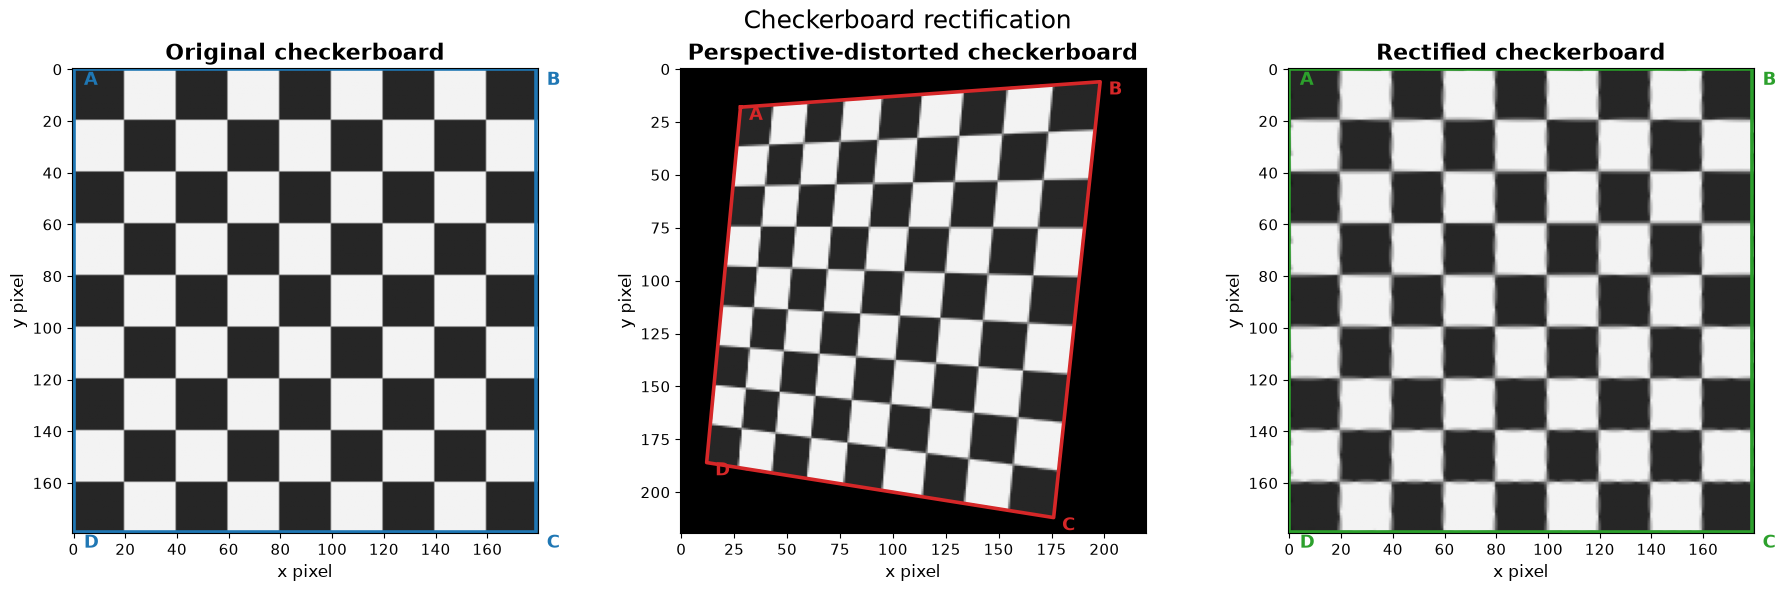

Rectification mean absolute error over valid rectified pixels: 0.0294


In [96]:
corner_labels = ["A", "B", "C", "D"]
rectified_corners = src_corners.clone()

fig, axes = plt.subplots(1, 3, figsize=(18.2, 5.8), constrained_layout=True)

panel_specs = [
    (axes[0], checkerboard, src_corners, "tab:blue", "Original checkerboard"),
    (axes[1], distorted_checkerboard, dst_corners, "tab:red", "Perspective-distorted checkerboard"),
    (axes[2], rectified_checkerboard, rectified_corners, "tab:green", "Rectified checkerboard"),
]

for ax, image, corners, color, title in panel_specs:
    ax.imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
    loop = torch.cat([corners, corners[:1]], dim=0)
    ax.plot(*loop.T, color=color, linewidth=2.6)
    for label, (x, y) in zip(corner_labels, corners.tolist()):
        ax.text(x + 4, y + 6, label, color=color, fontsize=13, weight="bold")
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

fig.suptitle("Checkerboard rectification", fontsize=18)
save_figure(fig, "fig41_05_checkerboard_rectification.png")
plt.show()

rectification_mae = (rectified_checkerboard[rectified_mask] - checkerboard[rectified_mask]).abs().mean().item()
print(f"Rectification mean absolute error over valid rectified pixels: {rectification_mae:.4f}")



Bilinear interpolation is needed because the inverse-mapped source coordinates are almost never integers. A destination pixel often lands between four source pixels, so we blend those neighbors instead of rounding to the nearest one. That keeps the synthetic perspective-correction example visually smoother and avoids staircase artifacts.

**What to notice:** the rectified board becomes geometrically fronto-parallel again, but interpolation slightly softens edges. That is expected and honest in this synthetic tutorial example.

This toy demo is still limited. The checkerboard is perfectly planar, the four corner correspondences are noise-free, there is no lens distortion, and the grayscale pattern has no occlusions or lighting changes. The rectification mean absolute error is therefore mainly a resampling artifact from applying bilinear interpolation twice, not a claim that the recovered image is mathematically exact. Real photographs add many more complications, so this PyTorch implementation of DLT/RANSAC/inverse warping should be read as an educational homography demo rather than a full image stitching system.


## Parameter Study

Two practical questions matter in this synthetic tutorial example:

1. How does measurement noise affect reprojection error?
2. How do outliers and the inlier threshold affect robust estimation?

The next experiments sweep over both parameters so we can see those trends directly.


Increasing noise weakens the precision of each correspondence, so reprojection error tends to rise even when the matches are still correct. Increasing the outlier ratio makes plain DLT fragile, while RANSAC remains stable only as long as it can still fit a useful model. The inlier threshold is a tradeoff: too small rejects noisy but valid points, while too large starts admitting outliers.

**What this figure shows:** the parameter-study figure separates noise sensitivity, outlier-driven error growth, and the threshold precision/recall tradeoff into different panels with different y-axis meanings.

**What to notice:** the first two panels are error plots, so their y-axis is a geometric error. The last panel is a rate/score plot, so its y-axis is unitless.

**Why this matters:** mixing geometric error and success metrics on the same axis can be visually misleading. Separating them keeps the teaching signal honest.



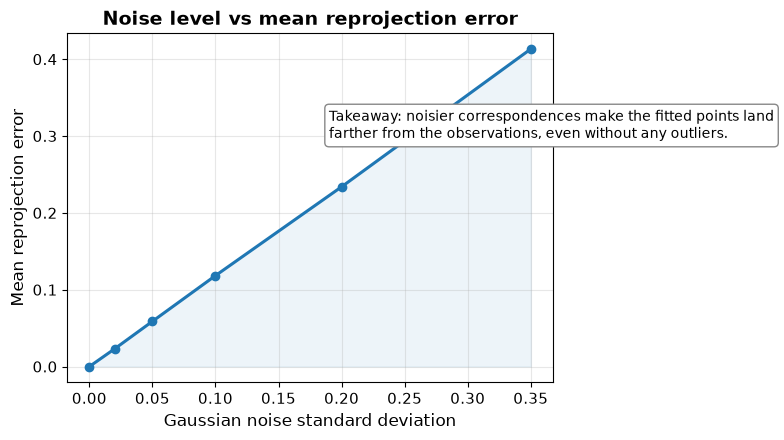

noise_std=0.00 -> mean error=0.0000
noise_std=0.02 -> mean error=0.0230
noise_std=0.05 -> mean error=0.0588
noise_std=0.10 -> mean error=0.1184
noise_std=0.20 -> mean error=0.2340
noise_std=0.35 -> mean error=0.4133


In [97]:
noise_levels = [0.0, 0.02, 0.05, 0.10, 0.20, 0.35]
noise_errors = []

for noise_std in noise_levels:
    trial_errors = []
    for _ in range(20):
        src, _, dst, _ = generate_correspondences(H_gt, noise_std=noise_std, outlier_ratio=0.0)
        H_est = estimate_homography_dlt(src, dst)
        trial_errors.append(compute_reprojection_error(H_est, src, dst).mean().item())
    noise_errors.append(sum(trial_errors) / len(trial_errors))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(noise_levels, noise_errors, marker="o", linewidth=2.2, color="tab:blue")
ax.fill_between(noise_levels, [0.0] * len(noise_levels), noise_errors, color="tab:blue", alpha=0.08)
ax.set_title("Noise level vs mean reprojection error")
ax.set_xlabel("Gaussian noise standard deviation")
ax.set_ylabel("Mean reprojection error")
ax.grid(True, alpha=0.3)
ax.text(
    0.19,
    max(noise_errors) * 0.72,
    "Takeaway: noisier correspondences make the fitted points land\nfarther from the observations, even without any outliers.",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#888888"),
)
plt.tight_layout()
plt.show()

for noise_std, err in zip(noise_levels, noise_errors):
    print(f"noise_std={noise_std:>4.2f} -> mean error={err:.4f}")


Saved figure: images/fig41_09_parameter_study.png


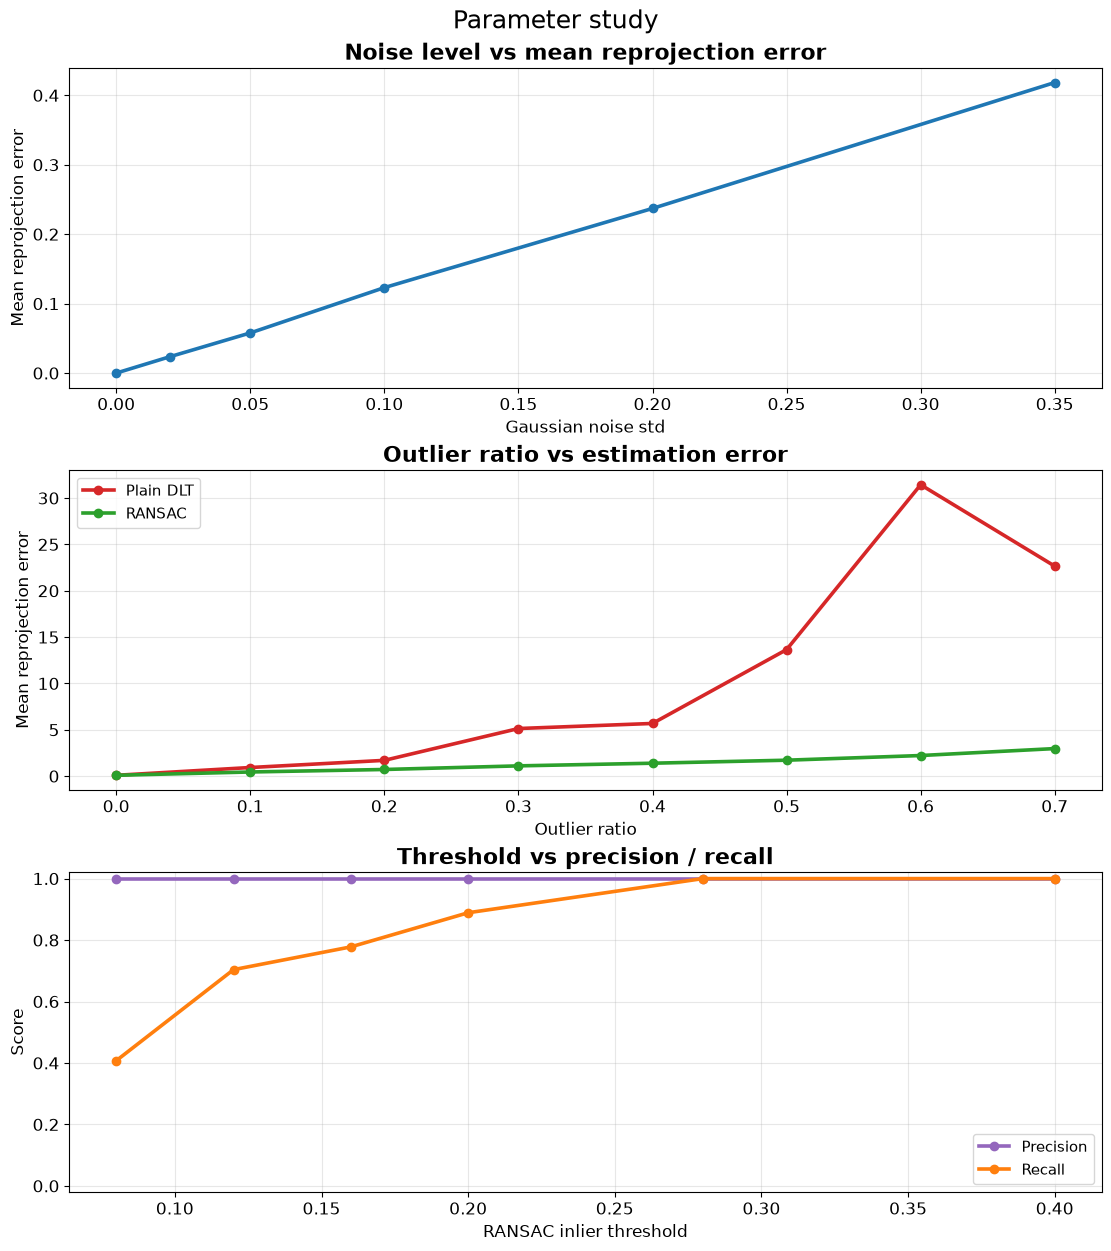

noise_std=0.00 -> mean error=0.0000
noise_std=0.02 -> mean error=0.0236
noise_std=0.05 -> mean error=0.0578
noise_std=0.10 -> mean error=0.1231
noise_std=0.20 -> mean error=0.2371
noise_std=0.35 -> mean error=0.4184

outlier_ratio=0.00 -> DLT mean error=0.090, RANSAC mean error=0.091
outlier_ratio=0.10 -> DLT mean error=0.931, RANSAC mean error=0.449
outlier_ratio=0.20 -> DLT mean error=1.703, RANSAC mean error=0.718
outlier_ratio=0.30 -> DLT mean error=5.137, RANSAC mean error=1.109
outlier_ratio=0.40 -> DLT mean error=5.685, RANSAC mean error=1.395
outlier_ratio=0.50 -> DLT mean error=13.651, RANSAC mean error=1.720
outlier_ratio=0.60 -> DLT mean error=31.436, RANSAC mean error=2.224
outlier_ratio=0.70 -> DLT mean error=22.654, RANSAC mean error=2.974

threshold=0.08 -> precision=1.00, recall=0.41
threshold=0.12 -> precision=1.00, recall=0.70
threshold=0.16 -> precision=1.00, recall=0.78
threshold=0.20 -> precision=1.00, recall=0.89
threshold=0.28 -> precision=1.00, recall=1.00
thres

In [98]:
noise_levels = [0.0, 0.02, 0.05, 0.10, 0.20, 0.35]
noise_errors = []

for noise_std in noise_levels:
    trial_errors = []
    for _ in range(20):
        src, _, dst, _ = generate_correspondences(H_gt, noise_std=noise_std, outlier_ratio=0.0)
        H_est = estimate_homography_dlt(src, dst)
        trial_errors.append(compute_reprojection_error(H_est, src, dst).mean().item())
    noise_errors.append(sum(trial_errors) / len(trial_errors))

outlier_ratios = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
dlt_reproj_errors = []
ransac_reproj_errors = []

for outlier_ratio in outlier_ratios:
    dlt_trials = []
    ransac_trials = []
    for _ in range(20):
        src, _, dst, _ = generate_correspondences(H_gt, noise_std=0.08, outlier_ratio=outlier_ratio)
        H_dlt_trial = estimate_homography_dlt(src, dst)
        dlt_trials.append(compute_reprojection_error(H_dlt_trial, src, dst).mean().item())
        try:
            H_est, _, _ = ransac_homography(src, dst, threshold=0.20, num_iters=500)
            ransac_trials.append(compute_reprojection_error(H_est, src, dst).mean().item())
        except RuntimeError:
            pass
    dlt_reproj_errors.append(sum(dlt_trials) / len(dlt_trials))
    ransac_reproj_errors.append(sum(ransac_trials) / len(ransac_trials) if ransac_trials else float("nan"))

thresholds = [0.08, 0.12, 0.16, 0.20, 0.28, 0.40]
threshold_precisions = []
threshold_recalls = []
for threshold in thresholds:
    try:
        _, inliers_t, _ = ransac_homography(src_points, dst_points, threshold=threshold, num_iters=400)
        tp = int((inliers_t & true_inliers).sum().item())
        precision_t = tp / max(int(inliers_t.sum().item()), 1)
        recall_t = tp / max(int(true_inliers.sum().item()), 1)
    except RuntimeError:
        precision_t = 0.0
        recall_t = 0.0
    threshold_precisions.append(precision_t)
    threshold_recalls.append(recall_t)

fig, axes = plt.subplots(3, 1, figsize=(11.0, 12.4), constrained_layout=True)
axes[0].plot(noise_levels, noise_errors, marker="o", linewidth=2.6, color="tab:blue")
axes[0].set_title("Noise level vs mean reprojection error", fontsize=16)
axes[0].set_xlabel("Gaussian noise std")
axes[0].set_ylabel("Mean reprojection error")
axes[0].tick_params(labelsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(outlier_ratios, dlt_reproj_errors, marker="o", linewidth=2.6, color="tab:red", label="Plain DLT")
axes[1].plot(outlier_ratios, ransac_reproj_errors, marker="o", linewidth=2.6, color="tab:green", label="RANSAC")
axes[1].set_title("Outlier ratio vs estimation error", fontsize=16)
axes[1].set_xlabel("Outlier ratio")
axes[1].set_ylabel("Mean reprojection error")
axes[1].tick_params(labelsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left", frameon=True)

axes[2].plot(thresholds, threshold_precisions, marker="o", linewidth=2.6, color="#9467bd", label="Precision")
axes[2].plot(thresholds, threshold_recalls, marker="o", linewidth=2.6, color="tab:orange", label="Recall")
axes[2].set_title("Threshold vs precision / recall", fontsize=16)
axes[2].set_xlabel("RANSAC inlier threshold")
axes[2].set_ylabel("Score")
axes[2].set_ylim(-0.02, 1.02)
axes[2].tick_params(labelsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="lower right", frameon=True)

fig.suptitle("Parameter study", fontsize=18)
save_figure(fig, "fig41_09_parameter_study.png")
plt.show()

for noise_std, err in zip(noise_levels, noise_errors):
    print(f"noise_std={noise_std:>4.2f} -> mean error={err:.4f}")
print()
for outlier_ratio, dlt_err, ransac_err in zip(outlier_ratios, dlt_reproj_errors, ransac_reproj_errors):
    print(f"outlier_ratio={outlier_ratio:>4.2f} -> DLT mean error={dlt_err:.3f}, RANSAC mean error={ransac_err:.3f}")
print()
for threshold, precision_t, recall_t in zip(thresholds, threshold_precisions, threshold_recalls):
    print(f"threshold={threshold:>4.2f} -> precision={precision_t:.2f}, recall={recall_t:.2f}")



## Failure Case: Degeneracy and Extreme Outliers

Homography estimation needs well-conditioned correspondences. Two common problems are:

- **Nearly collinear points**: the DLT system becomes poorly constrained because the points do not span the full 2D projective transformation.
- **Too many outliers**: RANSAC may not sample enough all-inlier minimal sets.

We will demonstrate both.

**What this figure shows:** the left panel emphasizes the narrow 1D support band, while the right panel shows a field dominated by outliers with only a few surviving inliers.

**What to notice:** low error on a thin strip of points does not mean the homography is stable over the full plane, and overwhelming outliers can defeat even a robust estimator.

**Takeaway:** good homography estimation needs both clean matches and good spatial coverage.



Saved figure: images/fig41_10_failure_cases.png


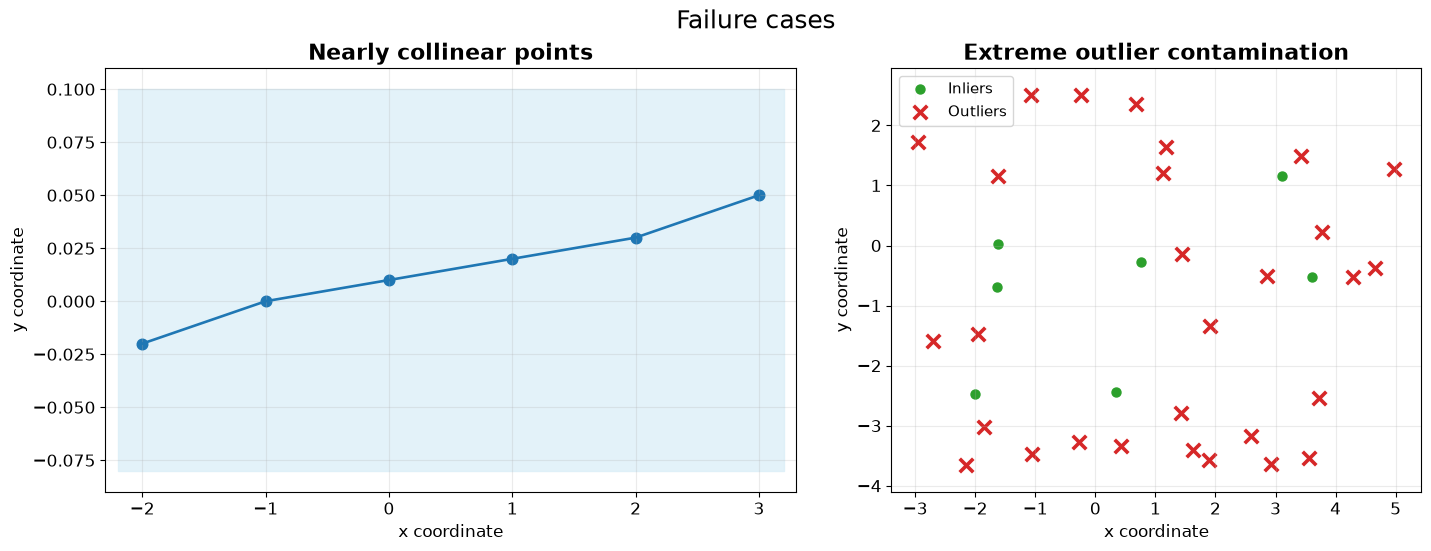

Nearly collinear case
  Mean reprojection error: 0.01114608979396258
  Matrix error vs ground truth: 2.925947915959425

Extreme-outlier RANSAC case
  succeeded, matrix error=1.425, inlier ratio=0.17


In [99]:
collinear_src = torch.tensor(
    [
        [-2.0, -0.02],
        [-1.0,  0.00],
        [ 0.0,  0.01],
        [ 1.0,  0.02],
        [ 2.0,  0.03],
        [ 3.0,  0.05],
    ]
)
collinear_dst = apply_homography(collinear_src, H_gt)
collinear_dst = collinear_dst + 0.01 * torch.randn_like(collinear_dst)

H_collinear = estimate_homography_dlt(collinear_src, collinear_dst)
collinear_error = compute_reprojection_error(H_collinear, collinear_src, collinear_dst).mean().item()
collinear_matrix_error = torch.linalg.norm(normalize_homography_scale(H_collinear) - normalize_homography_scale(H_gt)).item()

src_hard, _, dst_hard, true_inliers_hard = generate_correspondences(H_gt, noise_std=0.08, outlier_ratio=0.80)
try:
    H_hard, hard_inliers, hard_info = ransac_homography(src_hard, dst_hard, threshold=0.20, num_iters=500)
    hard_matrix_error = torch.linalg.norm(normalize_homography_scale(H_hard) - normalize_homography_scale(H_gt)).item()
    hard_status = f"succeeded, matrix error={hard_matrix_error:.3f}, inlier ratio={hard_info['inlier_ratio']:.2f}"
except RuntimeError as exc:
    hard_status = f"failed: {exc}"

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.4), constrained_layout=True)
axes[0].fill_between([-2.2, 3.2], [-0.08, -0.08], [0.10, 0.10], color="#d9edf7", alpha=0.72)
axes[0].plot(collinear_src[:, 0], collinear_src[:, 1], color="tab:blue", linewidth=1.9)
axes[0].scatter(collinear_src[:, 0], collinear_src[:, 1], color="tab:blue", s=58)
axes[0].set_title("Nearly collinear points", fontsize=16)
axes[0].set_xlabel("x coordinate")
axes[0].set_ylabel("y coordinate")
axes[0].set_xlim(-2.3, 3.3)
axes[0].set_ylim(-0.09, 0.11)
axes[0].tick_params(labelsize=12)
axes[0].grid(True, alpha=0.25)

axes[1].scatter(dst_hard[true_inliers_hard, 0], dst_hard[true_inliers_hard, 1], color="tab:green", s=42, label="Inliers")
axes[1].scatter(dst_hard[~true_inliers_hard, 0], dst_hard[~true_inliers_hard, 1], color="tab:red", s=95, marker="x", linewidths=2.6, label="Outliers")
axes[1].set_title("Extreme outlier contamination", fontsize=16)
axes[1].set_xlabel("x coordinate")
axes[1].set_ylabel("y coordinate")
axes[1].set_aspect("equal")
axes[1].tick_params(labelsize=12)
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper left", frameon=True)
set_geometry_limits(axes[1], dst_hard, pad=0.45)

fig.suptitle("Failure cases", fontsize=18)
save_figure(fig, "fig41_10_failure_cases.png")
plt.show()

print("Nearly collinear case")
print("  Mean reprojection error:", collinear_error)
print("  Matrix error vs ground truth:", collinear_matrix_error)
print()
print("Extreme-outlier RANSAC case")
print(" ", hard_status)



## Summary and Reproducibility Notes

We used PyTorch to implement a **beginner-friendly visual homography tutorial** from scratch:

- homogeneous coordinate conversion,
- point normalization,
- normalized DLT,
- reprojection error,
- RANSAC-based robust fitting,
- and inverse image warping for a synthetic perspective-correction example.

The synthetic experiments highlighted four useful takeaways:

1. normalized DLT works well when correspondences are clean and well spread out,
2. RANSAC is essential when mismatches are present,
3. inverse warping turns the estimated homography into a dense image-rectification tool,
4. degeneracy and extreme outlier rates can still defeat the estimator.

### Reproducibility

- The notebook uses only synthetic data.
- Random seeds are fixed at the top of the notebook.
- All computations are CPU-friendly.
- The implementation avoids OpenCV for core estimation and core inverse warping so the math is easy to inspect.
- The checkerboard rectification metric should be interpreted as a small resampling error, not as an exact pixel-recovery guarantee.
- Key teaching figures are also saved into `images/` so they can be reused outside the notebook.

A natural extension is to replace the synthetic corners with real detections and study how interpolation, occlusions, and imperfect corner localization affect rectification quality.
